In [1]:
# Cell 1: Imports and configuration
from dataclasses import dataclass
from pathlib import Path
import wave
import csv

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from IPython.display import Audio, display

TRAIN_DIR = Path("../../TinHieuHuanLuyen")
TEST_DIR = Path("../../TinHieuKiemThu")
OUTPUT_DIR = Path("output/mine")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Fixed DSP parameters
FRAME_MS = 25         # frame length (ms)
HOP_MS = 10           # frame hop (ms)
MIN_SILENCE_MS = 200  # minimum silence duration (ms)


In [2]:
# Cell 2: Data loading and feature extraction (Giannakopoulos, 2014)
@dataclass
class Sample:
    """Audio sample with precomputed features and ground-truth boundaries."""
    name: str
    signal: np.ndarray
    fs: int
    ste: np.ndarray            # normalized short-time energy [0, 1]
    sc: np.ndarray             # normalized spectral centroid [0, 1]
    frame_starts: np.ndarray   # frame start times (s)
    gt: tuple                  # ground-truth (start, end) in seconds

    @property
    def duration(self):
        return len(self.signal) / self.fs


def read_wav(wav_path):
    """Read 16-bit PCM WAV file, normalize amplitude to [-1, 1]."""
    with wave.open(str(wav_path), "rb") as wf:
        fs = wf.getframerate()
        raw = wf.readframes(wf.getnframes())
    signal = np.frombuffer(raw, dtype=np.int16).astype(float)
    return signal / max(np.max(np.abs(signal)), 1.0), fs


def read_speech_bounds(lab_path):
    """Read speech boundaries (start, end) spanning 'v' and 'uv' segments."""
    segments = []
    for line in lab_path.read_text(encoding="utf-8").splitlines():
        parts = line.split()
        if len(parts) == 3 and parts[2].lower() in {"v", "uv"}:
            segments.append((float(parts[0]), float(parts[1])))
    return round(min(s for s, _ in segments), 4), round(max(e for _, e in segments), 4)


def compute_features(signal, fs, frame_ms=FRAME_MS, hop_ms=HOP_MS):
    """Compute normalized STE and Spectral Centroid for each frame."""
    frame_size = int(round(frame_ms * fs / 1000.0))
    hop_size = int(round(hop_ms * fs / 1000.0))
    n_frames = max(1, int(np.ceil(max(0, len(signal) - frame_size) / hop_size)) + 1)

    bin_index = np.arange(1, frame_size // 2 + 2)
    n_bins = len(bin_index)

    ste = np.zeros(n_frames)
    sc = np.zeros(n_frames)
    frame_starts = np.arange(n_frames) * hop_size / fs

    for i in range(n_frames):
        chunk = signal[i * hop_size : i * hop_size + frame_size]
        frame = np.zeros(frame_size)
        frame[:len(chunk)] = chunk  # zero-pad last frame

        ste[i] = np.mean(frame ** 2)

        magnitude = np.abs(np.fft.rfft(frame))
        total = magnitude.sum()
        if total > 1e-12:
            sc[i] = np.sum(bin_index * magnitude) / (total * n_bins)

    return ste / max(ste.max(), 1e-12), sc / max(sc.max(), 1e-12), frame_starts


def load_dataset(data_dir):
    """Load WAV files, LAB ground truth, and precompute features."""
    samples = []
    for wav_path in sorted(data_dir.glob("*.wav")):
        signal, fs = read_wav(wav_path)
        ste, sc, frame_starts = compute_features(signal, fs)
        gt = read_speech_bounds(wav_path.with_suffix(".lab"))
        samples.append(Sample(wav_path.name, signal, fs, ste, sc, frame_starts, gt))
    return samples


train_set = load_dataset(TRAIN_DIR)
test_set = load_dataset(TEST_DIR)
print(f"Loaded {len(train_set)} train files and {len(test_set)} test files")


Loaded 4 train files and 4 test files


In [3]:
# Cell 3: Two-feature histogram VAD (Giannakopoulos, 2014)
@dataclass
class HistogramThreshold:
    """Adaptive threshold and histogram data of one feature."""
    value: float          # T = (W * M1 + M2) / (W + 1)
    m1: float             # first local maximum (silence peak)
    m2: float             # second local maximum (speech peak)
    centers: np.ndarray   # bin centers
    counts: np.ndarray    # raw histogram counts
    smooth: np.ndarray    # smoothed histogram counts


@dataclass
class VADResult:
    start: float            # speech start (s)
    end: float              # speech end (s)
    labels: np.ndarray      # final decision (1 = speech, 0 = silence)
    raw_labels: np.ndarray     # after STE AND SC thresholding
    filled_labels: np.ndarray  # after bridging silences < 200 ms
    energy: HistogramThreshold
    centroid: HistogramThreshold


class HistogramVAD:
    """Adaptive VAD based on STE and Spectral Centroid histograms."""

    def __init__(self, bins=100, smoothing_width=5, weight_e=5.0, weight_c=5.0,
                 pad_start=0, pad_end=0):
        self.bins = bins
        self.smoothing_width = smoothing_width
        self.weight_e = weight_e
        self.weight_c = weight_c
        self.pad_start = pad_start
        self.pad_end = pad_end

    def _smooth(self, counts):
        """Smooth histogram using a moving average window."""
        half = self.smoothing_width // 2
        return np.array([counts[max(0, i - half): i + half + 1].mean() for i in range(len(counts))])

    @staticmethod
    def _first_two_peaks(smooth):
        """Find the first two local maxima from left to right (M1 silence, M2 speech)."""
        peaks = []
        if smooth[0] >= smooth[1]:
            peaks.append(0)
        peaks += [i for i in range(1, len(smooth) - 1)
                  if smooth[i] > smooth[i - 1] and smooth[i] >= smooth[i + 1]]
        if len(peaks) >= 2:
            return peaks[0], peaks[1]

        # Fallback for unimodal histograms
        first = int(np.argmax(smooth))
        candidates = [i for i in range(len(smooth)) if abs(i - first) > 2]
        second = max(candidates, key=lambda i: smooth[i]) if candidates else min(first + 3, len(smooth) - 1)
        return tuple(sorted((first, second)))

    def estimate_threshold(self, values, weight):
        """Compute smoothed histogram and adaptive threshold T = (W*M1 + M2) / (W + 1)."""
        counts, edges = np.histogram(values, bins=self.bins, range=(float(values.min()), float(values.max())))
        centers = (edges[:-1] + edges[1:]) / 2.0
        smooth = self._smooth(counts)
        i1, i2 = self._first_two_peaks(smooth)
        m1, m2 = float(centers[i1]), float(centers[i2])
        return HistogramThreshold((weight * m1 + m2) / (weight + 1.0), m1, m2, centers, counts, smooth)

    @staticmethod
    def _fill_short_silences(labels, first, last, min_frames):
        """Bridge silent gaps shorter than min_frames between speech frames."""
        idx = first
        while idx <= last:
            if labels[idx] == 1:
                idx += 1
                continue
            gap_start = idx
            while idx <= last and labels[idx] == 0:
                idx += 1
            if idx - gap_start < min_frames:
                labels[gap_start:idx] = 1

    def predict(self, sample):
        """Detect the speech region of an audio sample."""
        energy = self.estimate_threshold(sample.ste, self.weight_e)
        centroid = self.estimate_threshold(sample.sc, self.weight_c)
        labels = ((sample.ste >= energy.value) & (sample.sc >= centroid.value)).astype(int)
        raw_labels = labels.copy()

        speech = np.flatnonzero(labels)
        if len(speech) == 0:
            return VADResult(0.0, 0.0, labels, raw_labels, raw_labels, energy, centroid)
        first, last = int(speech[0]), int(speech[-1])

        # Fill spurious silences < 200 ms
        self._fill_short_silences(labels, first, last, int(round(MIN_SILENCE_MS / HOP_MS)))
        filled_labels = labels.copy()

        # Extend boundaries outward
        start_idx = max(0, first - self.pad_start)
        end_idx = min(len(labels) - 1, last + self.pad_end)
        labels[start_idx:first] = 1
        labels[last + 1:end_idx + 1] = 1

        start = float(sample.frame_starts[start_idx])
        end = min(sample.duration, float(sample.frame_starts[end_idx]) + FRAME_MS / 1000.0)
        return VADResult(round(start, 4), round(end, 4), labels, raw_labels, filled_labels, energy, centroid)


In [4]:
# Cell 4: Evaluation helpers and TRAIN baseline (No Padding)
@dataclass
class Evaluation:
    """Evaluation result and boundary errors (ms) of one sample."""
    sample: Sample
    result: VADResult
    d_start: float
    d_end: float

    @property
    def mae(self):
        return (abs(self.d_start) + abs(self.d_end)) / 2.0

    @property
    def rmse(self):
        return float(np.sqrt((self.d_start ** 2 + self.d_end ** 2) / 2.0))


def evaluate(samples, vad):
    """Run VAD on dataset and compute boundary errors (ms)."""
    evaluations = []
    for sample in samples:
        result = vad.predict(sample)
        d_start = (result.start - sample.gt[0]) * 1000.0
        d_end = (result.end - sample.gt[1]) * 1000.0
        evaluations.append(Evaluation(sample, result, d_start, d_end))
    return evaluations


def mean_mae(evaluations):
    return float(np.mean([e.mae for e in evaluations]))


def mean_rmse(evaluations):
    return float(np.mean([e.rmse for e in evaluations]))


def print_report(title, evaluations):
    """Print per-file table of thresholds, boundaries and errors."""
    header = (f"{'File':<16} | {'T_E (STE)':<10} | {'T_C (SC)':<10} | {'Ground truth':<16} | {'Predicted':<16} | "
              f"{'ΔStart':<9} | {'ΔEnd':<9} | {'MAE (ms)':<9} | {'RMSE (ms)':<9}")
    width = len(header)
    print("=" * width)
    print(f"{title:^{width}}")
    print("=" * width)
    print(header)
    print("-" * width)
    for e in evaluations:
        gt = f"[{e.sample.gt[0]:.2f}, {e.sample.gt[1]:.2f}]"
        pred = f"[{e.result.start:.2f}, {e.result.end:.2f}]"
        print(f"{e.sample.name:<16} | {e.result.energy.value:<10.4f} | {e.result.centroid.value:<10.4f} | "
              f"{gt:<16} | {pred:<16} | {e.d_start:+7.1f}ms | {e.d_end:+7.1f}ms | {e.mae:9.2f} | {e.rmse:9.2f}")
    print("-" * width)
    print(f"Mean MAE = {mean_mae(evaluations):.2f} ms  |  Mean RMSE = {mean_rmse(evaluations):.2f} ms")
    print("=" * width)


vad_baseline = HistogramVAD(pad_start=0, pad_end=0)
train_eval_baseline = evaluate(train_set, vad_baseline)
print_report("TRAIN SET - BASELINE (NO PADDING)", train_eval_baseline)


                                               TRAIN SET - BASELINE (NO PADDING)                                                
File             | T_E (STE)  | T_C (SC)   | Ground truth     | Predicted        | ΔStart    | ΔEnd      | MAE (ms)  | RMSE (ms)
--------------------------------------------------------------------------------------------------------------------------------
phone_F1.wav     | 0.0153     | 0.1540     | [0.53, 2.75]     | [0.54, 2.75]     |   +10.0ms |    -5.0ms |      7.50 |      7.91
phone_M1.wav     | 0.0220     | 0.1814     | [0.46, 3.52]     | [0.48, 3.52]     |   +20.0ms |    +5.0ms |     12.50 |     14.58
studio_F1.wav    | 0.0150     | 0.2084     | [0.68, 2.15]     | [0.67, 2.15]     |   -10.0ms |    -5.0ms |      7.50 |      7.91
studio_M1.wav    | 0.0150     | 0.2115     | [0.87, 2.06]     | [0.91, 2.04]     |   +40.0ms |   -15.0ms |     27.50 |     30.21
-------------------------------------------------------------------------------------------------

pad_start  pad_end  Train MAE (ms)
----------------------------------
1          0                 11.25
1          1                 11.25
2          0                 11.25
2          1                 11.25
0          0                 13.75
0          1                 13.75
3          1                 13.75
3          0                 13.75

Optimal symmetric configuration: pad_start = 1, pad_end = 1 (10 ms).
                                            TRAIN SET - WITH OPTIMAL PADDING (10 ms)                                            
File             | T_E (STE)  | T_C (SC)   | Ground truth     | Predicted        | ΔStart    | ΔEnd      | MAE (ms)  | RMSE (ms)
--------------------------------------------------------------------------------------------------------------------------------
phone_F1.wav     | 0.0153     | 0.1540     | [0.53, 2.75]     | [0.53, 2.75]     |    +0.0ms |    +5.0ms |      2.50 |      3.54
phone_M1.wav     | 0.0220     | 0.1814     | [0.46, 3.52]     | 

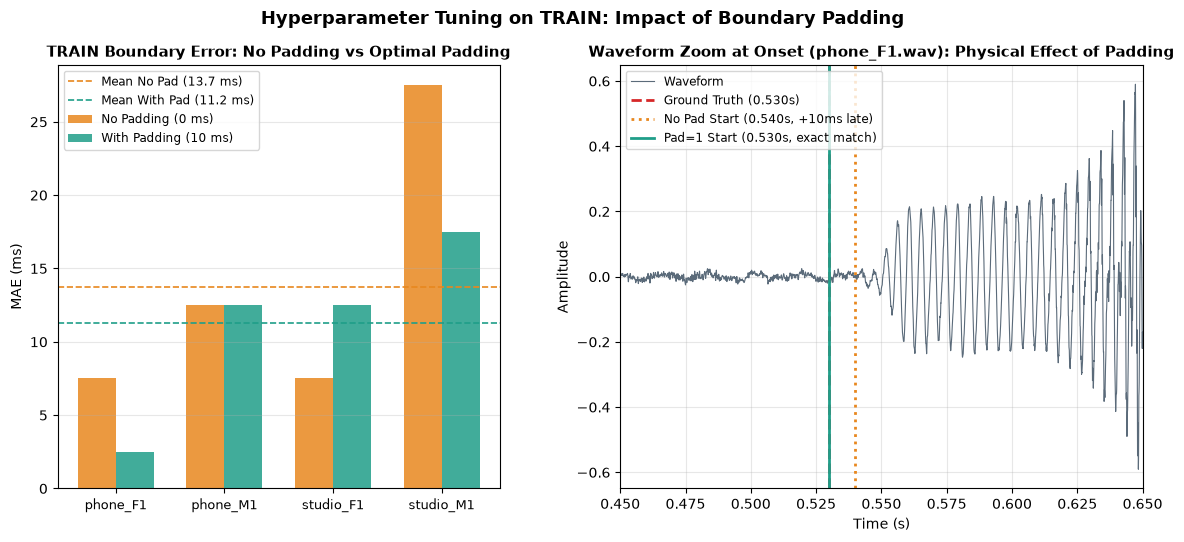

In [5]:
# Cell 5: Boundary-padding sweep and comparison on TRAIN
# Grid search boundary padding (0-4 frames = 0-40 ms) on TRAIN
MAX_PAD = 4

sweep = []
for pad_start in range(MAX_PAD + 1):
    for pad_end in range(MAX_PAD + 1):
        candidate = HistogramVAD(pad_start=pad_start, pad_end=pad_end)
        sweep.append((mean_mae(evaluate(train_set, candidate)), pad_start, pad_end))
sweep.sort()

print(f"{'pad_start':<10} {'pad_end':<8} {'Train MAE (ms)':>14}")
print("-" * 34)
for train_mae, pad_start, pad_end in sweep[:8]:
    print(f"{pad_start:<10} {pad_end:<8} {train_mae:>14.2f}")
print("\nOptimal symmetric configuration: pad_start = 1, pad_end = 1 (10 ms).")

# Evaluate TRAIN with optimal padding
vad_optimal = HistogramVAD(pad_start=1, pad_end=1)
train_eval_optimal = evaluate(train_set, vad_optimal)
print_report("TRAIN SET - WITH OPTIMAL PADDING (10 ms)", train_eval_optimal)

# Comparison summary
mae_nopad = [e.mae for e in train_eval_baseline]
mae_pad1 = [e.mae for e in train_eval_optimal]
names = [e.sample.name for e in train_eval_baseline]

print("\nImpact of Boundary Padding on TRAIN:")
print(f"• Baseline (No Pad)   : Mean MAE = {mean_mae(train_eval_baseline):.2f} ms")
print(f"• Optimal  (10 ms Pad): Mean MAE = {mean_mae(train_eval_optimal):.2f} ms "
      f"({(mean_mae(train_eval_optimal) - mean_mae(train_eval_baseline)) / mean_mae(train_eval_baseline) * 100:+.1f}%)")

# Plot comparison figure: MAE Bar Chart & Waveform Boundary Zoom
fig = plt.figure(figsize=(14, 5.5))
gs = fig.add_gridspec(1, 2, width_ratios=[1.1, 1.3], wspace=0.25)

# Subplot 1: Quantitative MAE comparison bar chart
ax_bar = fig.add_subplot(gs[0])
x = np.arange(len(names))
width = 0.35

rects1 = ax_bar.bar(x - width/2, mae_nopad, width, label='No Padding (0 ms)', color='#e8871e', alpha=0.85)
rects2 = ax_bar.bar(x + width/2, mae_pad1, width, label='With Padding (10 ms)', color='#1f9e89', alpha=0.85)

ax_bar.axhline(mean_mae(train_eval_baseline), color='#e8871e', linestyle='--', linewidth=1.2,
               label=f'Mean No Pad ({mean_mae(train_eval_baseline):.1f} ms)')
ax_bar.axhline(mean_mae(train_eval_optimal), color='#1f9e89', linestyle='--', linewidth=1.2,
               label=f'Mean With Pad ({mean_mae(train_eval_optimal):.1f} ms)')

ax_bar.set_title('TRAIN Boundary Error: No Padding vs Optimal Padding', fontsize=11, fontweight='bold')
ax_bar.set_ylabel('MAE (ms)')
ax_bar.set_xticks(x)
ax_bar.set_xticklabels([n.replace('.wav', '') for n in names], fontsize=9)
ax_bar.grid(axis='y', alpha=0.3)
ax_bar.legend(fontsize=8.5, loc='upper left')

# Subplot 2: Visual waveform zoom at boundary for a representative sample (phone_F1.wav)
rep_ev_nopad = train_eval_baseline[0]
rep_ev_pad1 = train_eval_optimal[0]
s = rep_ev_nopad.sample

t_wave = np.arange(len(s.signal)) / s.fs
t_start_zoom = (0.45, 0.65)
mask = (t_wave >= t_start_zoom[0]) & (t_wave <= t_start_zoom[1])

ax_zoom = fig.add_subplot(gs[1])
ax_zoom.plot(t_wave[mask], s.signal[mask], color='#5b6b7a', linewidth=0.8, label='Waveform')

ax_zoom.axvline(s.gt[0], color='#d62728', linestyle='--', linewidth=2.0, label=f'Ground Truth ({s.gt[0]:.3f}s)')
ax_zoom.axvline(rep_ev_nopad.result.start, color='#e8871e', linestyle=':', linewidth=2.0,
                label=f'No Pad Start ({rep_ev_nopad.result.start:.3f}s, +10ms late)')
ax_zoom.axvline(rep_ev_pad1.result.start, color='#1f9e89', linestyle='-', linewidth=2.0,
                label=f'Pad=1 Start ({rep_ev_pad1.result.start:.3f}s, exact match)')

ax_zoom.set_title(f'Waveform Zoom at Onset ({s.name}): Physical Effect of Padding', fontsize=11, fontweight='bold')
ax_zoom.set_xlabel('Time (s)')
ax_zoom.set_ylabel('Amplitude')
ax_zoom.set_xlim(t_start_zoom)
ax_zoom.grid(alpha=0.3)
ax_zoom.legend(fontsize=8.5, loc='upper left')

plt.suptitle('Hyperparameter Tuning on TRAIN: Impact of Boundary Padding', fontsize=13, fontweight='bold', y=0.98)
pad_fig_path = OUTPUT_DIR / 'padding_effect_comparison.png'
fig.savefig(pad_fig_path, dpi=150, bbox_inches='tight')
print(f"Saved figure: {pad_fig_path}")
plt.show()


In [6]:
# Cell 6: TEST results (Applying optimal padding from TRAIN)
test_eval = evaluate(test_set, vad_optimal)
print_report("TEST SET EVALUATION (OPTIMAL PAD = 10 ms)", test_eval)

# Check test without padding for reference
test_eval_nopad = evaluate(test_set, vad_baseline)
print("\nGeneralization to TEST Set:")
print(f"• Test MAE without padding: {mean_mae(test_eval_nopad):.2f} ms")
print(f"• Test MAE with 10 ms pad : {mean_mae(test_eval):.2f} ms "
      f"({(mean_mae(test_eval) - mean_mae(test_eval_nopad)) / mean_mae(test_eval_nopad) * 100:+.1f}%)")


                                           TEST SET EVALUATION (OPTIMAL PAD = 10 ms)                                            
File             | T_E (STE)  | T_C (SC)   | Ground truth     | Predicted        | ΔStart    | ΔEnd      | MAE (ms)  | RMSE (ms)
--------------------------------------------------------------------------------------------------------------------------------
phone_F2.wav     | 0.0167     | 0.1754     | [1.02, 4.04]     | [1.04, 4.03]     |   +20.0ms |   -15.0ms |     17.50 |     17.68
phone_M2.wav     | 0.0333     | 0.1918     | [0.53, 2.52]     | [0.55, 2.52]     |   +20.0ms |    +5.0ms |     12.50 |     14.58
studio_F2.wav    | 0.0150     | 0.0200     | [0.77, 2.37]     | [0.75, 2.35]     |   -20.0ms |   -15.0ms |     17.50 |     17.68
studio_M2.wav    | 0.0167     | 0.1618     | [0.45, 1.93]     | [0.45, 1.93]     |    +0.0ms |    -5.0ms |      2.50 |      3.54
-------------------------------------------------------------------------------------------------

In [7]:
# Cell 7: Intermediate results as tables & CSV

def intermediate_row(split, ev):
    r, s = ev.result, ev.sample
    return {
        "split": split, "file": s.name, "n_frames": len(r.labels),
        "M1_E": r.energy.m1, "M2_E": r.energy.m2, "T_E": r.energy.value,
        "M1_C": r.centroid.m1, "M2_C": r.centroid.m2, "T_C": r.centroid.value,
        "frames_after_AND": int(r.raw_labels.sum()),
        "frames_after_fill": int(r.filled_labels.sum()),
        "frames_final": int(r.labels.sum()),
        "gt_start": s.gt[0], "gt_end": s.gt[1],
        "pred_start": r.start, "pred_end": r.end,
        "d_start_ms": ev.d_start, "d_end_ms": ev.d_end,
        "mae_ms": ev.mae, "rmse_ms": ev.rmse,
    }


def print_table(title, rows, columns):
    cells = [[f"{row[key]:{fmt}}" for key, _, fmt in columns] for row in rows]
    widths = [max([len(header)] + [len(c[i]) for c in cells]) for i, (_, header, _) in enumerate(columns)]
    line = " | ".join(f"{header:>{w}}" for (_, header, _), w in zip(columns, widths))
    print(f"\n{title}")
    print("-" * len(line))
    print(line)
    print("-" * len(line))
    for c in cells:
        print(" | ".join(v.rjust(w) for v, w in zip(c, widths)))
    print("-" * len(line))


rows = ([intermediate_row("train", ev) for ev in train_eval_optimal]
        + [intermediate_row("test", ev) for ev in test_eval])

print_table("Histogram peaks and adaptive thresholds (T = (W*M1 + M2) / (W + 1))", rows, [
    ("split", "Split", ""), ("file", "File", ""),
    ("M1_E", "M1_E", ".4f"), ("M2_E", "M2_E", ".4f"), ("T_E", "T_E", ".4f"),
    ("M1_C", "M1_C", ".4f"), ("M2_C", "M2_C", ".4f"), ("T_C", "T_C", ".4f"),
])
print_table("Speech frames after each processing stage", rows, [
    ("split", "Split", ""), ("file", "File", ""), ("n_frames", "Frames", "d"),
    ("frames_after_AND", "STE AND SC", "d"), ("frames_after_fill", "Fill < 200 ms", "d"),
    ("frames_final", "Pad (final)", "d"),
])

csv_path = OUTPUT_DIR / "intermediate_results.csv"
with open(csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=list(rows[0]))
    writer.writeheader()
    writer.writerows({k: round(v, 4) if isinstance(v, float) else v for k, v in row.items()} for row in rows)
print(f"\nSaved table: {csv_path}")



Histogram peaks and adaptive thresholds (T = (W*M1 + M2) / (W + 1))
---------------------------------------------------------------------------
Split |          File |   M1_E |   M2_E |    T_E |   M1_C |   M2_C |    T_C
---------------------------------------------------------------------------
train |  phone_F1.wav | 0.0053 | 0.0653 | 0.0153 | 0.1305 | 0.2717 | 0.1540
train |  phone_M1.wav | 0.0054 | 0.1053 | 0.0220 | 0.1716 | 0.2305 | 0.1814
train | studio_F1.wav | 0.0050 | 0.0650 | 0.0150 | 0.2000 | 0.2503 | 0.2084
train | studio_M1.wav | 0.0050 | 0.0650 | 0.0150 | 0.2088 | 0.2247 | 0.2115
 test |  phone_F2.wav | 0.0051 | 0.0751 | 0.0167 | 0.1655 | 0.2248 | 0.1754
 test |  phone_M2.wav | 0.0050 | 0.1750 | 0.0333 | 0.1860 | 0.2208 | 0.1918
 test | studio_F2.wav | 0.0050 | 0.0650 | 0.0150 | 0.0050 | 0.0950 | 0.0200
 test | studio_M2.wav | 0.0050 | 0.0750 | 0.0167 | 0.1518 | 0.2115 | 0.1618
---------------------------------------------------------------------------

Speech frames afte

Saved figure: output/mine/train/phone_F1.png
Saved figure: output/mine/train/phone_M1.png
Saved figure: output/mine/train/studio_F1.png
Saved figure: output/mine/train/studio_M1.png
Saved figure: output/mine/test/phone_F2.png


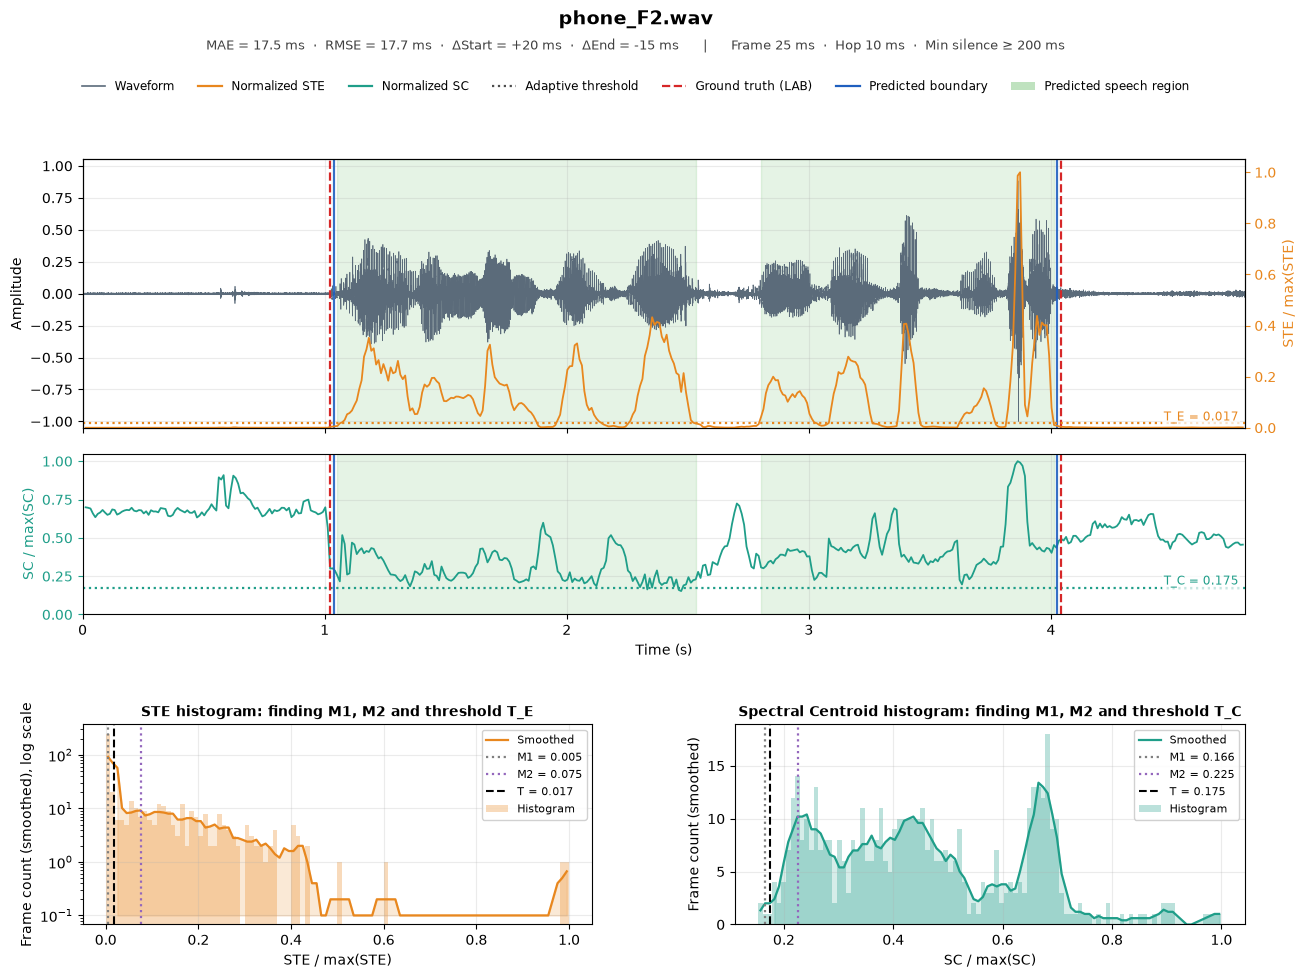

Original Audio (phone_F2.wav):


Detected Speech Segment [1.04s - 4.03s]:


Saved figure: output/mine/test/phone_M2.png


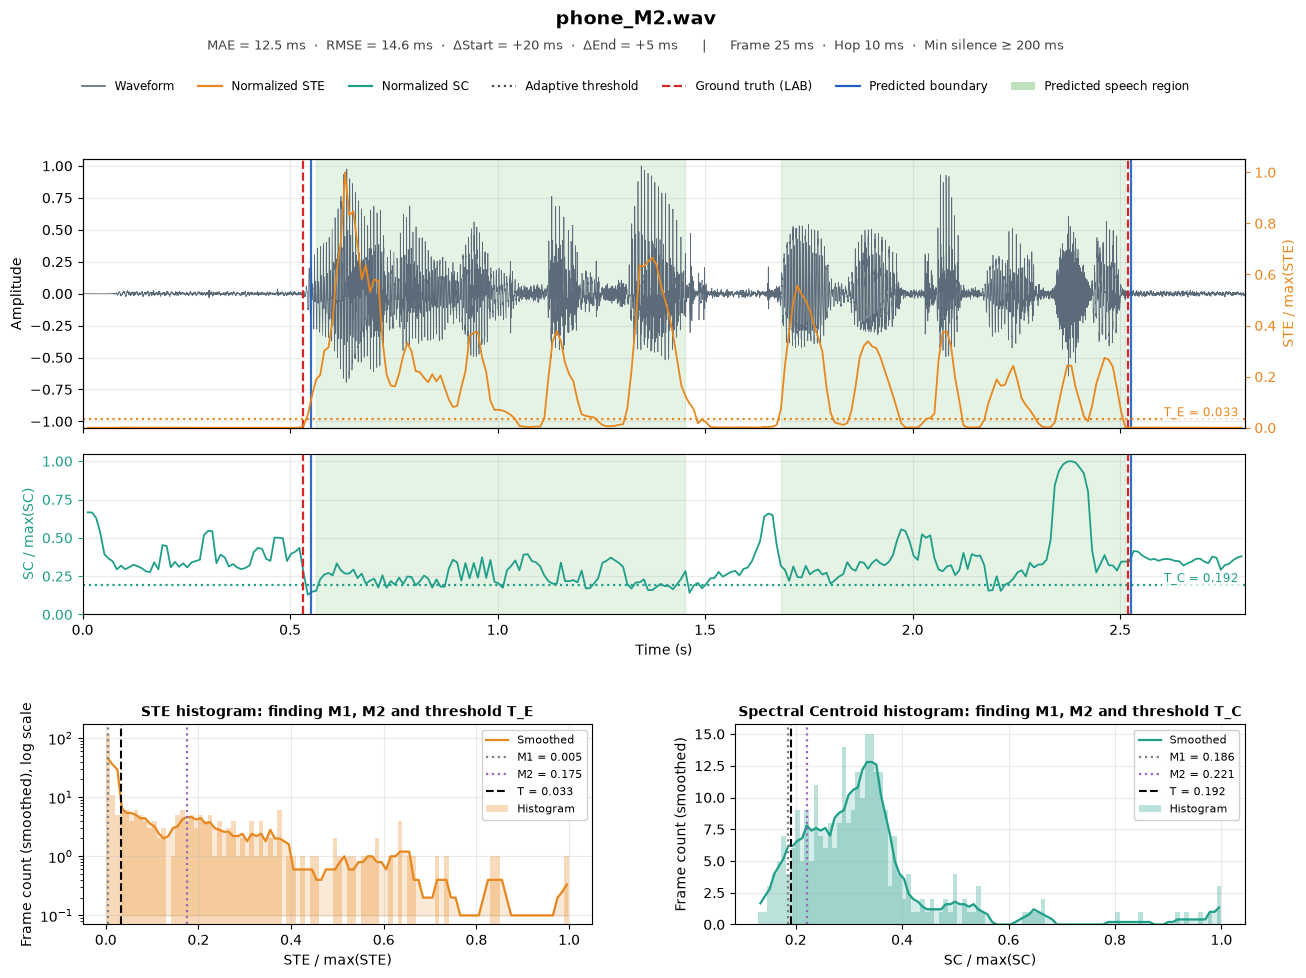

Original Audio (phone_M2.wav):


Detected Speech Segment [0.55s - 2.52s]:


Saved figure: output/mine/test/studio_F2.png


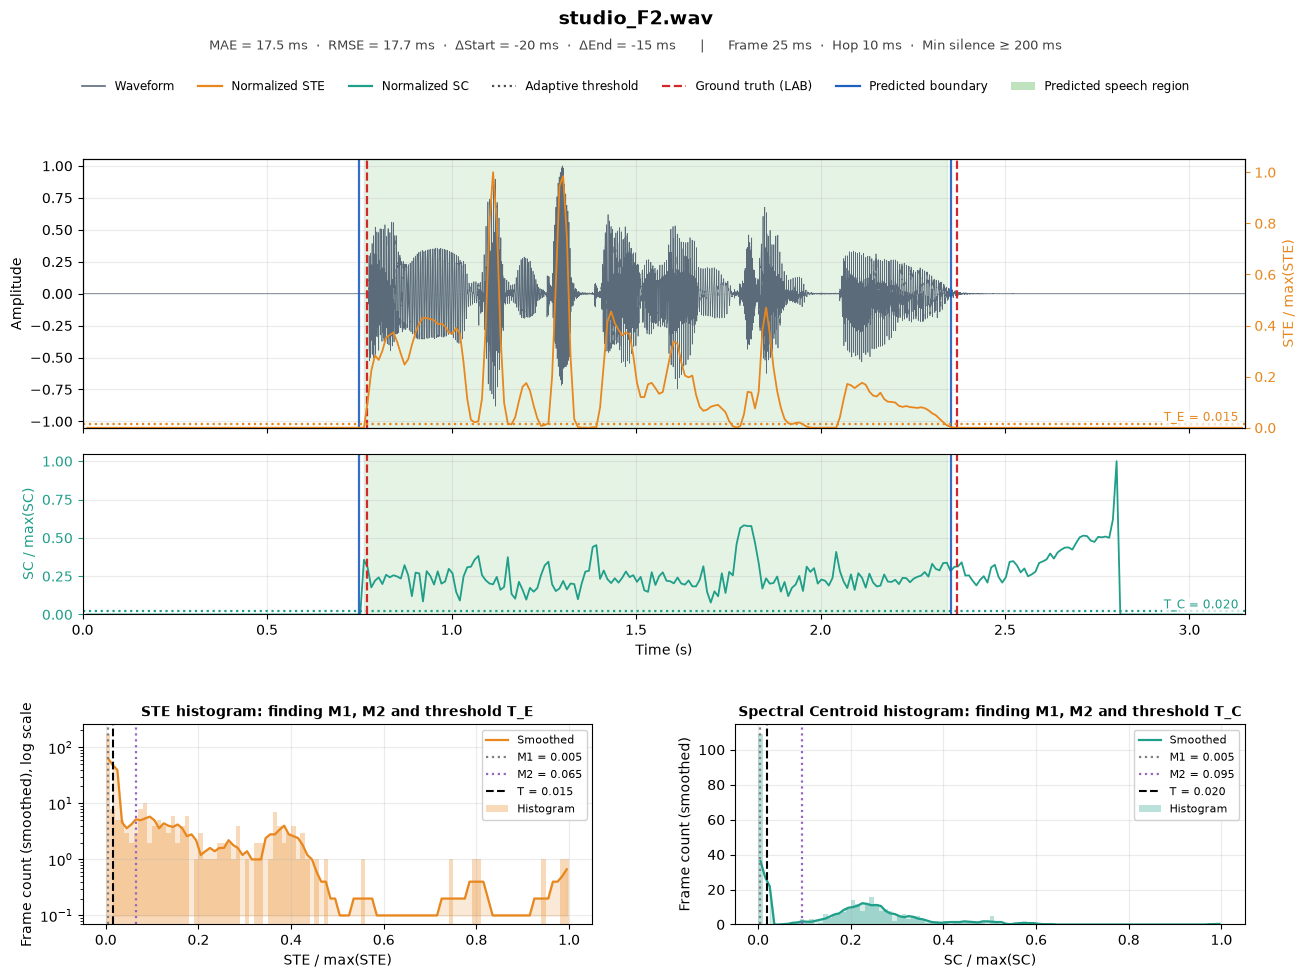

Original Audio (studio_F2.wav):


Detected Speech Segment [0.75s - 2.35s]:


Saved figure: output/mine/test/studio_M2.png


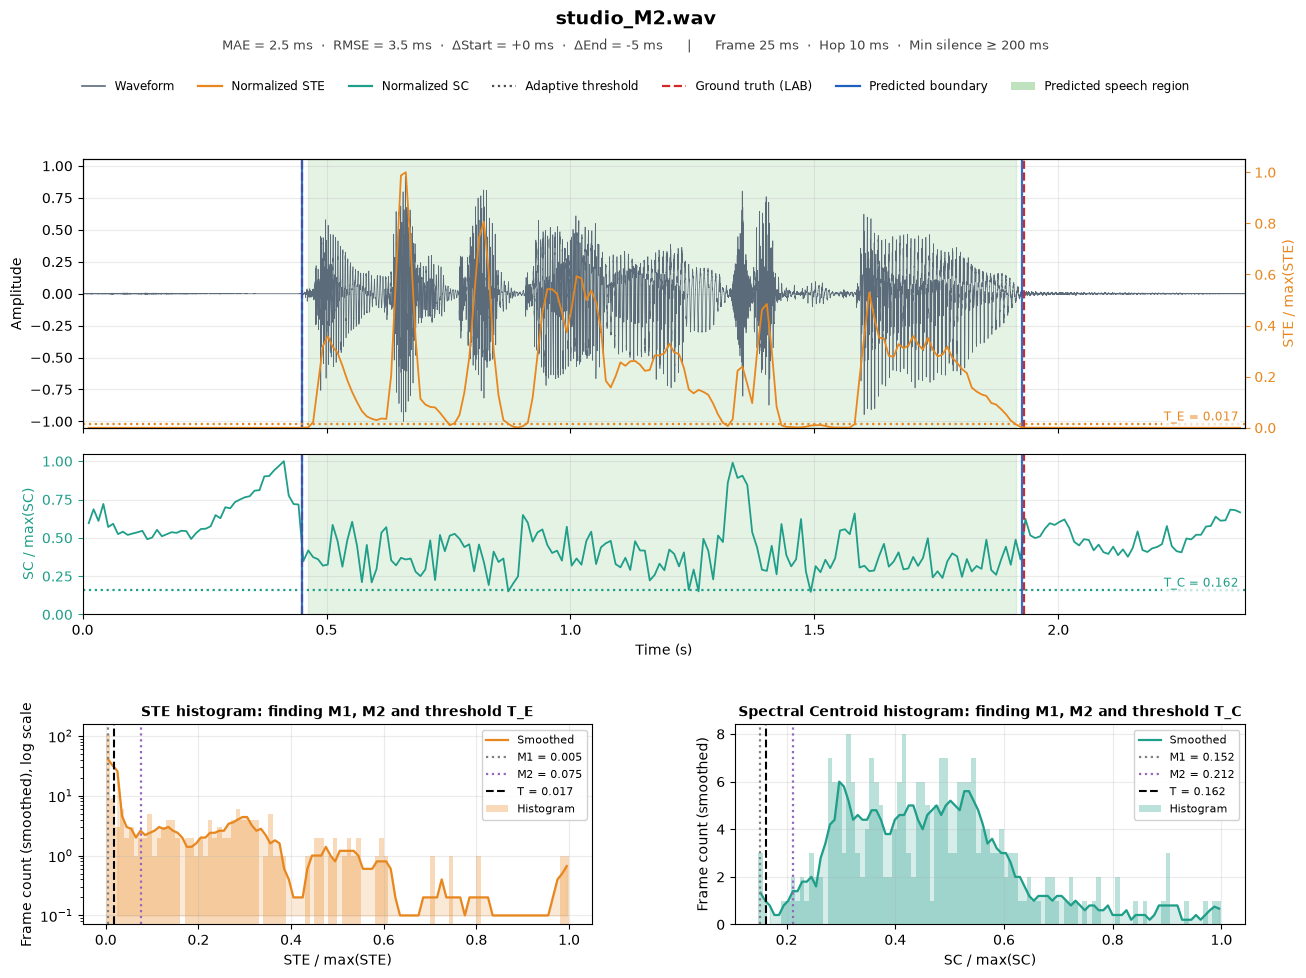

Original Audio (studio_M2.wav):


Detected Speech Segment [0.45s - 1.93s]:


In [8]:
# Cell 8: Detailed evaluation figures and audio players (TRAIN & TEST)
C_WAVE, C_STE, C_SC = "#5b6b7a", "#e8871e", "#1f9e89"
C_GT, C_PRED, C_SPEECH = "#d62728", "#1f5fbf", "#2ca02c"


def draw_boundaries(ax, gt, pred):
    for t in gt:
        ax.axvline(t, color=C_GT, linestyle="--", linewidth=1.6)
    for t in pred:
        ax.axvline(t, color=C_PRED, linestyle="-", linewidth=1.6, alpha=0.9)


def label_threshold(ax, x, y, text, color):
    ax.text(x, y, text, color=color, va="bottom", ha="right", fontsize=8.5,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.0))


def draw_histogram(ax, thr, color, title, xlabel, log_scale=False):
    y = np.maximum(thr.smooth, 0.1) if log_scale else thr.smooth
    base = 0.1 if log_scale else 0
    ax.bar(thr.centers, thr.counts, width=thr.centers[1] - thr.centers[0], color=color, alpha=0.3, label="Histogram")
    ax.plot(thr.centers, y, color=color, linewidth=1.6, label="Smoothed")
    ax.fill_between(thr.centers, base, y, where=thr.centers >= thr.value, color=color, alpha=0.18)
    ax.axvline(thr.m1, color="#7f7f7f", linestyle=":", linewidth=1.6, label=f"M1 = {thr.m1:.3f}")
    ax.axvline(thr.m2, color="#9467bd", linestyle=":", linewidth=1.6, label=f"M2 = {thr.m2:.3f}")
    ax.axvline(thr.value, color="black", linestyle="--", linewidth=1.5, label=f"T = {thr.value:.3f}")
    if log_scale:
        ax.set_yscale("log")
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Frame count (smoothed)" + (", log scale" if log_scale else ""))
    ax.grid(alpha=0.25)
    ax.legend(loc="best", fontsize=8, framealpha=0.9)


def plot_evaluation(ev, out_dir, show=True):
    sample, result = ev.sample, ev.result
    pred = (result.start, result.end)
    t_wave = np.arange(len(sample.signal)) / sample.fs
    t_frame = sample.frame_starts + FRAME_MS / 2000.0
    is_speech = result.labels == 1
    x_max = max(t_wave[-1], t_frame[-1])

    fig = plt.figure(figsize=(14, 10))
    left, right = 0.105, 0.935
    gs_top = fig.add_gridspec(2, 1, left=left, right=right, top=0.835, bottom=0.38, hspace=0.12,
                              height_ratios=[3.0, 1.8])
    gs_bot = fig.add_gridspec(1, 2, left=left, right=right, top=0.27, bottom=0.07, wspace=0.28)

    # (1) Waveform + STE
    ax1 = fig.add_subplot(gs_top[0])
    ax1.plot(t_wave, sample.signal, color=C_WAVE, linewidth=0.5)
    ax1.fill_between(t_frame, -1.05, 1.05, where=is_speech, step="mid", color=C_SPEECH, alpha=0.12)
    draw_boundaries(ax1, sample.gt, pred)
    ax1.set_ylim(-1.05, 1.05)
    ax1.set_ylabel("Amplitude")
    ax1.grid(alpha=0.25)
    ax1b = ax1.twinx()
    ax1b.plot(t_frame, sample.ste, color=C_STE, linewidth=1.3)
    ax1b.axhline(result.energy.value, color=C_STE, linestyle=":", linewidth=1.6)
    ax1b.set_ylim(0, 1.05)
    ax1b.set_ylabel("STE / max(STE)", color=C_STE)
    ax1b.tick_params(axis="y", colors=C_STE)
    label_threshold(ax1b, x_max * 0.995, result.energy.value, f"T_E = {result.energy.value:.3f}", C_STE)

    # (2) Spectral centroid
    ax2 = fig.add_subplot(gs_top[1], sharex=ax1)
    ax2.plot(t_frame, sample.sc, color=C_SC, linewidth=1.3)
    ax2.axhline(result.centroid.value, color=C_SC, linestyle=":", linewidth=1.6)
    ax2.fill_between(t_frame, 0, 1.05, where=is_speech, step="mid", color=C_SPEECH, alpha=0.12)
    draw_boundaries(ax2, sample.gt, pred)
    ax2.set_ylim(0, 1.05)
    ax2.set_ylabel("SC / max(SC)", color=C_SC)
    ax2.tick_params(axis="y", colors=C_SC)
    label_threshold(ax2, x_max * 0.995, result.centroid.value, f"T_C = {result.centroid.value:.3f}", C_SC)
    ax2.set_xlabel("Time (s)")
    ax2.set_xlim(0, x_max)
    ax2.grid(alpha=0.25)
    plt.setp(ax1.get_xticklabels(), visible=False)

    # (3) Histograms of both features
    draw_histogram(fig.add_subplot(gs_bot[0]), result.energy, C_STE,
                   "STE histogram: finding M1, M2 and threshold T_E", "STE / max(STE)", log_scale=True)
    draw_histogram(fig.add_subplot(gs_bot[1]), result.centroid, C_SC,
                   "Spectral Centroid histogram: finding M1, M2 and threshold T_C", "SC / max(SC)")

    # (4) Title and legend
    fig.suptitle(sample.name, fontsize=14, fontweight="bold", y=0.985)
    fig.text(0.5, 0.945,
             f"MAE = {ev.mae:.1f} ms  ·  RMSE = {ev.rmse:.1f} ms  ·  ΔStart = {ev.d_start:+.0f} ms  ·  ΔEnd = {ev.d_end:+.0f} ms"
             f"      |      Frame {FRAME_MS} ms  ·  Hop {HOP_MS} ms  ·  Min silence ≥ {MIN_SILENCE_MS} ms",
             ha="center", fontsize=9.5, color="0.25")
    handles = [
        Line2D([0], [0], color=C_WAVE, linewidth=1.2, label="Waveform"),
        Line2D([0], [0], color=C_STE, linewidth=1.6, label="Normalized STE"),
        Line2D([0], [0], color=C_SC, linewidth=1.6, label="Normalized SC"),
        Line2D([0], [0], color="0.3", linestyle=":", linewidth=1.6, label="Adaptive threshold"),
        Line2D([0], [0], color=C_GT, linestyle="--", linewidth=1.6, label="Ground truth (LAB)"),
        Line2D([0], [0], color=C_PRED, linewidth=1.6, label="Predicted boundary"),
        Patch(facecolor=C_SPEECH, alpha=0.3, label="Predicted speech region"),
    ]
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 0.925), ncol=7, fontsize=8.5, frameon=False)

    out_dir.mkdir(parents=True, exist_ok=True)
    fig_path = out_dir / f"{Path(sample.name).stem}.png"
    fig.savefig(fig_path, dpi=150)
    print(f"Saved figure: {fig_path}")
    if show:
        plt.show()

        # Embedded audio players: original signal and detected speech segment
        print(f"Original Audio ({sample.name}):")
        display(Audio(data=sample.signal, rate=sample.fs))

        st_idx = int(result.start * sample.fs)
        en_idx = min(len(sample.signal), int(result.end * sample.fs))
        if en_idx > st_idx:
            print(f"Detected Speech Segment [{result.start:.2f}s - {result.end:.2f}s]:")
            display(Audio(data=sample.signal[st_idx:en_idx], rate=sample.fs))
    else:
        plt.close(fig)


for ev in train_eval_optimal:
    plot_evaluation(ev, OUTPUT_DIR / "train", show=False)
for ev in test_eval:
    plot_evaluation(ev, OUTPUT_DIR / "test")
